-------

# LEVEL 1

## EXERCISE 1

Connect Python with MySQL Workbench and load the data from your Sprint 4 database to use it in all the exercises.

----


In [21]:
!pip install seaborn matplotlib plotly pandas squarify dotenv mysql-connector-python

import squarify
from matplotlib.ticker import FuncFormatter
import numpy as np
from mysql.connector.abstracts import MySQLConnectionAbstract
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv
import mysql.connector
from mysql.connector import Error


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
load_dotenv()

host = os.getenv("MYSQL_HOST")
port = os.getenv("MYSQL_PORT")
user = os.getenv("MYSQL_USER")
password = os.getenv("MYSQL_PASSWORD")
database = os.getenv("MYSQL_DATABASE")

config = {
  'user': user,
  'password': password,
  'host': host,
  'database': database,
    'port': port,
  'raise_on_warnings': True
}

def get_connection():
    return mysql.connector.connect(**config)


In [23]:
try:
    connection = get_connection()
    cursor = connection.cursor()
    query = "SELECT DATABASE();"
    cursor.execute(query)
    db_name = cursor.fetchone()
    print("Connected to: ", db_name)

except Error as e:
    print(e)

finally:
    if connection.is_connected():
        cursor.close()
        connection.close()
    print("Disconnected from database")


Connected to:  ('transactions_sprint_4_1',)
Disconnected from database


In [24]:
def get_dataframe(query):
    try:
        connection = get_connection()
        return pd.read_sql(query, connection)
    except Error as e:
        print(e)
    finally:
        if connection.is_connected():
            connection.close()


In [25]:

tables = get_dataframe("SHOW TABLES")
tables

C:\Users\raari\AppData\Local\Temp\ipykernel_60748\151428039.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, connection)


,Tables_in_transactions_sprint_4_1
0,card_status
1,companies
2,credit_cards
3,products
4,transactions
5,transactions_products
6,users


In [26]:
dictionary_of_dfs = {}
for df_name in tables.iloc[:, 0]:
    dictionary_of_dfs[df_name] = get_dataframe(f"SELECT * FROM {df_name}")
    print(f" - {df_name} loaded: {dictionary_of_dfs[df_name].size} rows")


 - card_status loaded: 10000 rows
 - companies loaded: 600 rows


C:\Users\raari\AppData\Local\Temp\ipykernel_60748\151428039.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, connection)


 - credit_cards loaded: 45000 rows
 - products loaded: 600 rows
 - transactions loaded: 1000000 rows
 - transactions_products loaded: 506782 rows
 - users loaded: 50000 rows



------


## EXERCISE 2

For each element, create an appropriate view according to the specified variables. Interpret the results based on your data.


------



In [27]:

# Transform name of tables to work easier

companies = dictionary_of_dfs['companies']
credit_cards = dictionary_of_dfs['credit_cards']
card_status = dictionary_of_dfs['card_status']
products = dictionary_of_dfs['products']
transactions = dictionary_of_dfs['transactions']
transactions_products = dictionary_of_dfs['transactions_products']
users = dictionary_of_dfs['users']

------
#### 1 NUMERIC VARIABLE



------


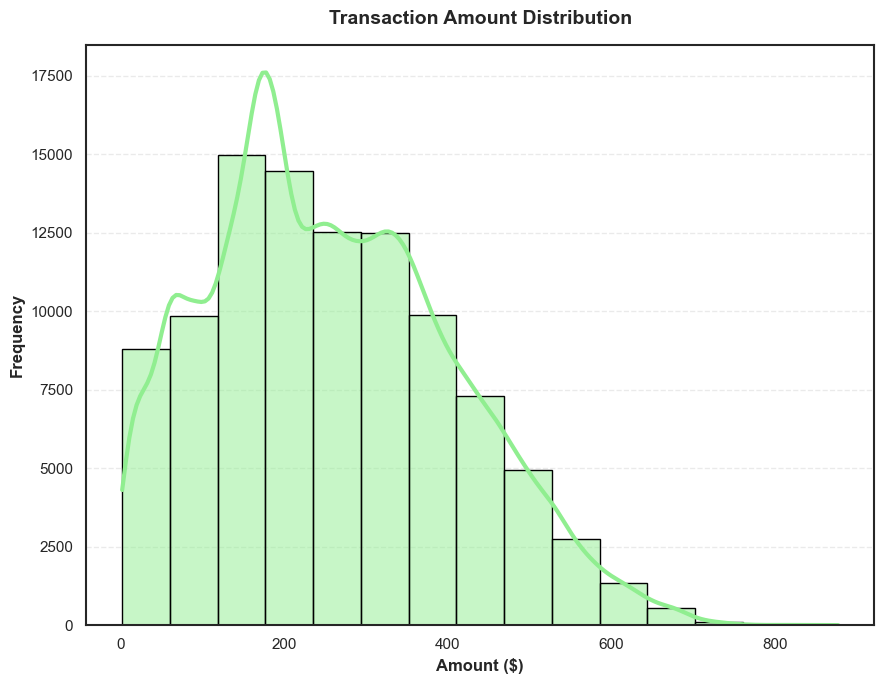

In [28]:


def draw_transaction_amount_distribution():
    # Data cleaning
    data = pd.to_numeric(dictionary_of_dfs["transactions"]['amount'], errors='coerce').dropna()

    # Figure and plot configuration
    plt.figure(figsize=(9, 7))
    ax = sns.histplot(data, bins=15, color='lightgreen', edgecolor='black', kde=True,
                      line_kws={'color': '#1b5e20', 'linewidth': 3})

    # Frame and Grid setup (ONLY Horizontal)
    plt.setp(ax.spines.values(), visible=True, linewidth=1.5)
    ax.xaxis.grid(False) # Explicitly disable vertical grid
    ax.yaxis.grid(True, linestyle='--', alpha=0.4) # Enable only horizontal grid

    # Titles and labels
    plt.title("Transaction Amount Distribution", fontsize=14, weight='bold', pad=15)
    plt.xlabel("Amount ($)", weight='bold')
    plt.ylabel("Frequency", weight='bold')

    plt.tight_layout()
    plt.show()

draw_transaction_amount_distribution()

CONCLUSIONS:
- Peak Frequency: The highest concentration of transactions occurs around the 150  to  200 $ range, where the frequency reaches approximately 17,500

- Common Range: Most transactions are clustered between 0 and 400 $

- Trend: As the transaction amount increases beyond 400,the frequency steadily declines,with very few transactions recorded above 700 $ *
- The gaussian curve es not very simmetric


-----
#### 2 NUMERIC VARIABLES
------


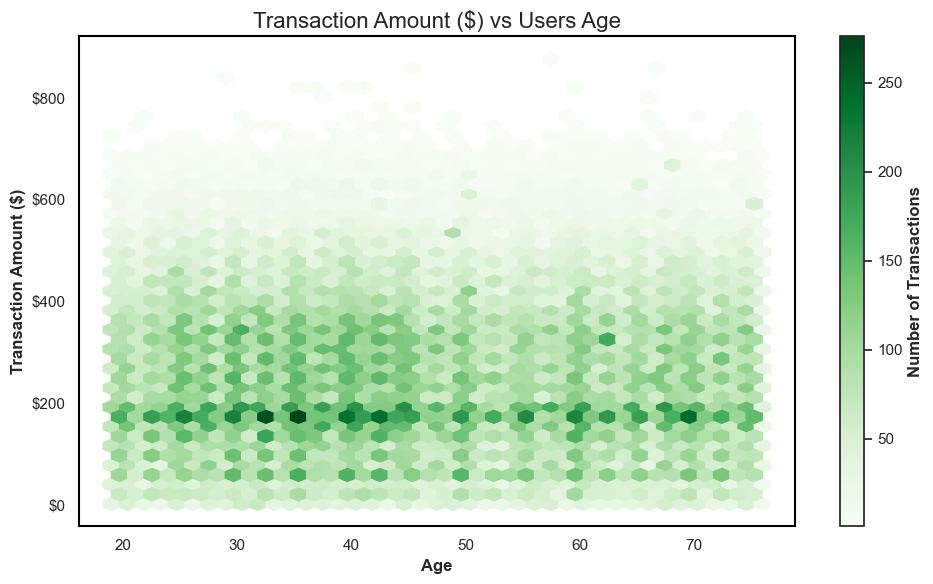

In [29]:

# Age calculation
users['birth_date'] = pd.to_datetime(users['birth_date'], errors='coerce')
current_date = pd.Timestamp.today()
users['age'] = (current_date - users['birth_date']).dt.days // 365

# Data Merging
sales_df= transactions.merge(users, on='user_id', how='inner')

# Visualization Setup
fig, ax = plt.subplots(figsize=(10, 6))

hb = ax.hexbin(
    sales_df['age'],
    sales_df['amount'],
    gridsize=40,
    cmap='Greens',
    mincnt=1
)

# --- FRAME AND GRID SETTINGS ---
ax.grid(False)  # Remove any background grid
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)


# Titles and Axis Labels
ax.set_title('Transaction Amount ($) vs Users Age', fontsize=16)
ax.set_xlabel('Age', fontsize=12, weight='bold')
ax.set_ylabel('Transaction Amount ($)', fontsize=12, weight='bold')

# Format Y-axis as currency
ax.yaxis.set_major_formatter(FuncFormatter(lambda val, pos: f'${val:,.0f}'.replace(',', '.')))

# Colorbar setup
colorbar = fig.colorbar(hb, ax=ax)
colorbar.set_label('Number of Transactions', weight='bold')

plt.tight_layout()
plt.show()



CONCLUSIONS:
- The frequency of transactions is highest for amounts between 100 and 400 dollars,with a prominent peak around 180 dollars

- As the amount increases beyond 500 dollars, the frequency drops significantly,showing very few transactions above $800


----
### 1 CATEGORICAL VARIABLE
----

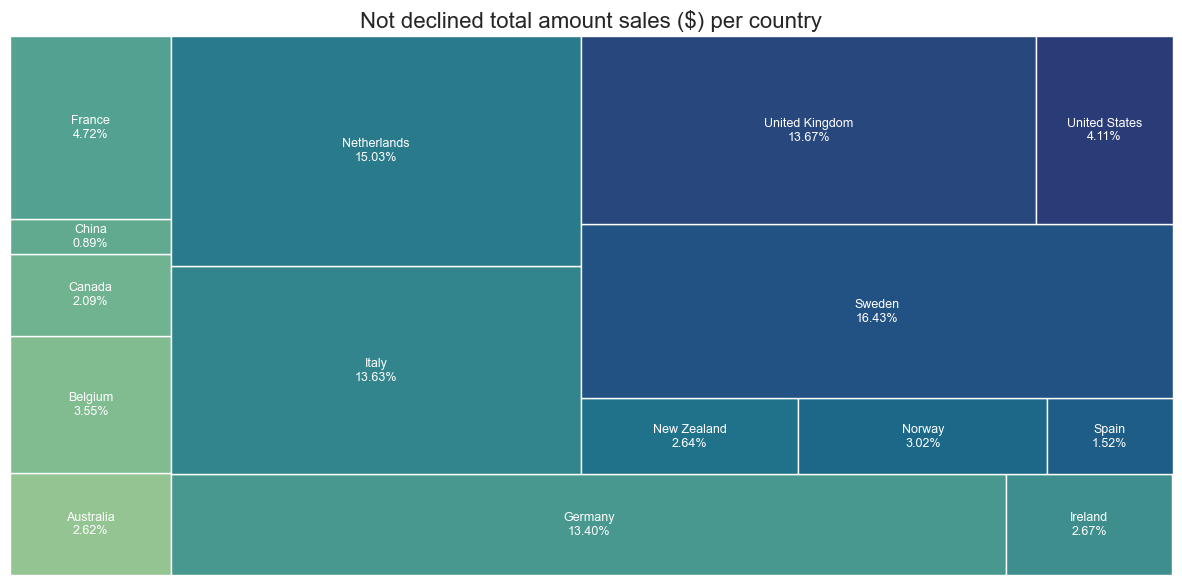

In [30]:

accepted_transactions = transactions[transactions['declined'] == 0]

transactions_with_companies = accepted_transactions.merge(
    companies[['company_id', 'country']],
    on='company_id',
    how='left'
)

country_sales_sum = transactions_with_companies.groupby('country')['amount'].sum().reset_index()
total_amount = country_sales_sum['amount'].sum()
percentages = [(amount / total_amount) * 100 for amount in country_sales_sum['amount']]

sizes = country_sales_sum['amount']
labels = country_sales_sum['country']

fig, ax = plt.subplots(figsize=(15, 7))

colors = sns.color_palette("crest", len(sizes))

squarify.plot(
    sizes=sizes,
    label=[f"{country}\n{pct:.2f}%" for country, pct in zip(labels, percentages)],
    color=colors,
    ax=ax,
    edgecolor='white',
    text_kwargs={'color': 'white', 'fontsize': 9}
)

plt.title("Not declined total amount sales ($) per country", fontsize=16)
plt.axis('off')

plt.show()


CONCLUSSIONS:

- Sweden is the leading country, accounting for the largest share of sales at 16.43%
- Concentrated Sales: A significant majority of the total sales volume is concentrated in five countries: Sweden, Netherlands (15.03%), United Kingdom (13.67%), Italy (13.63%), and Germany (13.40%)
Together, these five nations represent approximately 72.16% of the total amount
- European Dominance: The chart is heavily dominated by European nations, which hold the top six spots and represent the vast majority of the total sales value displayed
- North American and Oceanic Presence: Outside of Europe, the United States is the largest contributor at 4.11%, followed by Australia (2.62%), New Zealand (2.64%), and Canada (2.09%)
- Lowest Contribution: China represents the smallest share of the "not declined" sales amount among the listed countries, at only 0.89%
- Tiered Distribution: There is a sharp drop-off in sales volume after the top five countries (all >13%) to the next tier, which begins with France at 4.72%


----
#### 1 CATEGORICAL AND 1 NUMERICAL VARIABLES
----

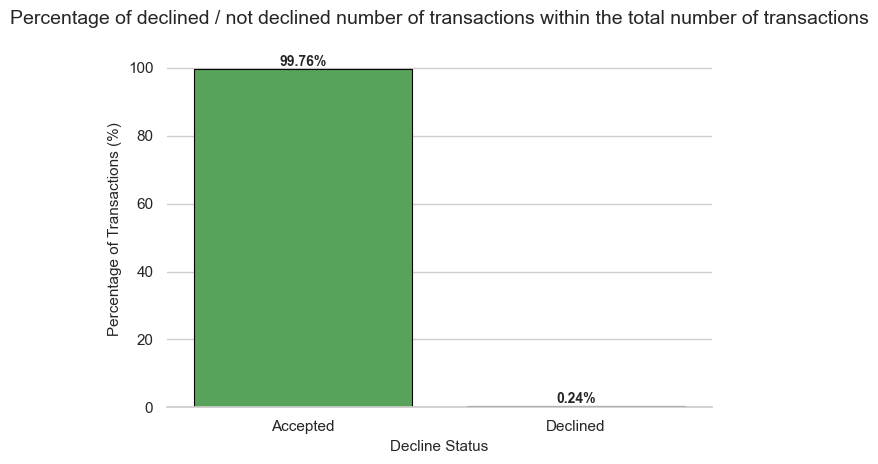

Total Transactions: 100000
Accepted Transactions: 99763 (99.76%)
Declined Transactions: 237 (0.24%)


In [31]:

total_transactions = len(transactions)
declined_count = len(transactions[transactions['declined'] == 1])
accepted_count = len(transactions[transactions['declined'] == 0])

declined_percentage = (declined_count / total_transactions) * 100
accepted_percentage = (accepted_count / total_transactions) * 100

# Create a DataFrame for the barplot
df_percentages = pd.DataFrame({
    "decline_status": ["Accepted", "Declined"],
    "percentage": [accepted_percentage, declined_percentage]
})

sns.set_theme(style="whitegrid")

custom_palette = ["#4CAF50", "#E53935"]

barplot = sns.barplot(
    data=df_percentages,
    x="decline_status",
    y="percentage",
    hue="decline_status",
    palette=custom_palette,
    errorbar=None,
    edgecolor="black",
    linewidth=0.8
)

barplot.set_title("Percentage of declined / not declined number of transactions within the total number of transactions", fontsize=14, pad=20)
barplot.set_xlabel("Decline Status", fontsize=11)
barplot.set_ylabel("Percentage of Transactions (%)", fontsize=11)

# Remove legend only if it exists
if barplot.legend_:
    barplot.legend_.remove()

for p in barplot.patches:
    height = p.get_height()
    barplot.annotate(
        f"{height:.2f}%",
        (p.get_x() + p.get_width() / 2, height),
        ha="center",
        va="bottom",
        fontsize=10,
        weight="semibold"
    )

sns.despine(ax=barplot, left=True)

plt.tight_layout()
plt.show()


print(f"Total Transactions: {total_transactions}")
print(f"Accepted Transactions: {accepted_count} ({accepted_percentage:.2f}%)")
print(f"Declined Transactions: {declined_count} ({declined_percentage:.2f}%)")

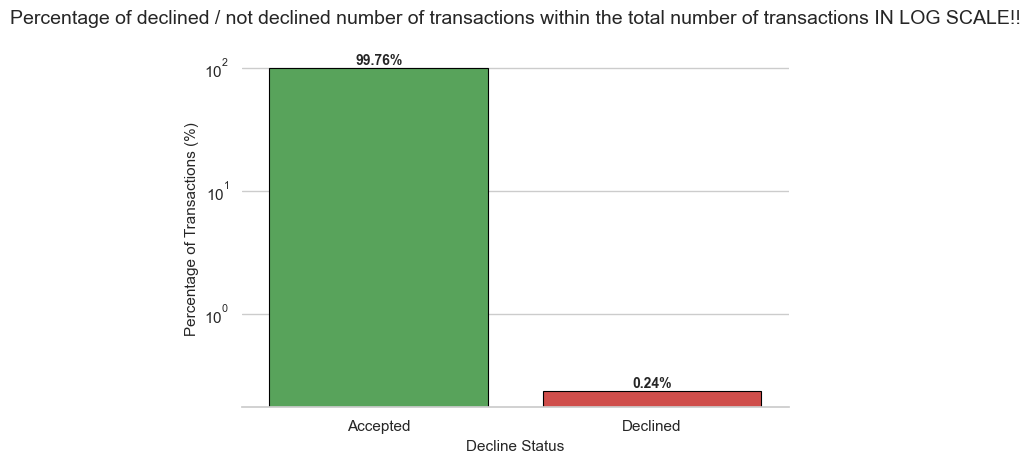

Total Transactions: 100000
Accepted Transactions: 99763 (99.76%)
Declined Transactions: 237 (0.24%)


In [32]:
total_transactions = len(transactions)
declined_count = len(transactions[transactions['declined'] == 1])
accepted_count = len(transactions[transactions['declined'] == 0])

declined_percentage = (declined_count / total_transactions) * 100
accepted_percentage = (accepted_count / total_transactions) * 100

df_percentages = pd.DataFrame({
    "decline_status": ["Accepted", "Declined"],
    "percentage": [accepted_percentage, declined_percentage]
})


sns.set_theme(style="whitegrid")

custom_palette = ["#4CAF50", "#E53935"]

barplot = sns.barplot(
    data=df_percentages,
    x="decline_status",
    y="percentage",
    hue="decline_status",
    palette=custom_palette,
    errorbar=None,
    edgecolor="black",
    linewidth=0.8
)

barplot.set_title("Percentage of declined / not declined number of transactions within the total number of transactions IN LOG SCALE!!", fontsize=14, pad=20)
barplot.set_xlabel("Decline Status", fontsize=11)
barplot.set_ylabel("Percentage of Transactions (%)", fontsize=11)

# Apply logarithmic scale to Y-axis
barplot.set_yscale("log")

# Remove legend only if it exists
if barplot.legend_:
    barplot.legend_.remove()

for p in barplot.patches:
    height = p.get_height()
    barplot.annotate(
        f"{height:.2f}%",
        (p.get_x() + p.get_width() / 2, height),
        ha="center",
        va="bottom",
        fontsize=10,
        weight="semibold"
    )

sns.despine(ax=barplot, left=True)

plt.tight_layout()
plt.show()


print(f"Total Transactions: {total_transactions}")
print(f"Accepted Transactions: {accepted_count} ({accepted_percentage:.2f}%)")
print(f"Declined Transactions: {declined_count} ({declined_percentage:.2f}%)")

CONCLUSSION:

Only 0,24 % of all the transactions have been declined

----
### 2 CATEGORICAL VARIABLES
----

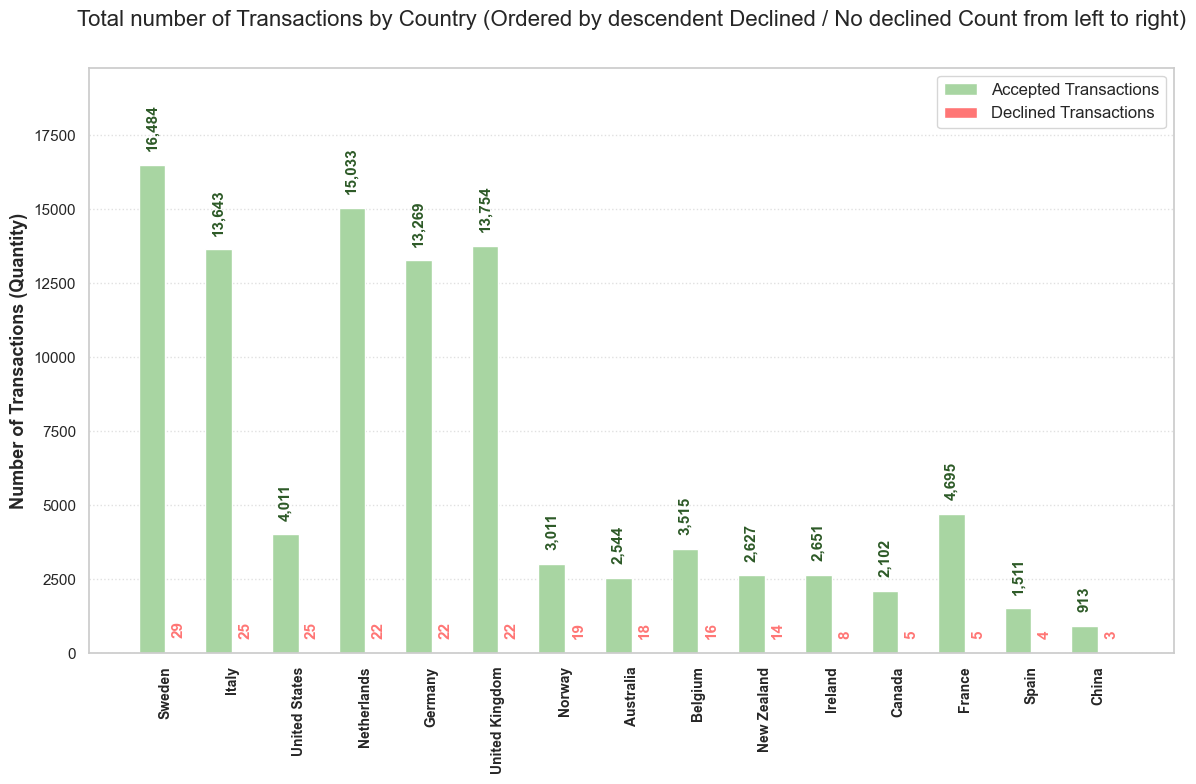

In [33]:

# Merge transactions with companies to include the 'country' column
df = transactions.merge(companies[['company_id', 'country']], on='company_id', how='left')

# Aggregation: Transaction COUNT (using count instead of sum)
# Group by country and status, then pivot to have 'Accepted' and 'Declined' as columns
pivot_df = df.groupby(['country', 'declined'])['transaction_id'].count().unstack(fill_value=0)
pivot_df.columns = ['Accepted', 'Declined']

# Sort by the number of 'Declined' transactions in descending order
pivot_df = pivot_df.sort_values(by='Declined', ascending=False)

# Plot
countries = pivot_df.index
x = np.arange(len(countries))
width = 0.4
fig, ax = plt.subplots(figsize=(12, 8))
rects1 = ax.bar(x - width/2, pivot_df['Accepted'], width, label='Accepted Transactions', color='#a8d5a2')
rects2 = ax.bar(x + width/2, pivot_df['Declined'], width, label='Declined Transactions', color='#ff7675')
ax.set_ylabel('Number of Transactions (Quantity)', fontsize=13, fontweight='bold')
ax.set_title('Total number of Transactions by Country (Ordered by descendent Declined / No declined Count from left to right)', fontsize=16, pad=30)
ax.set_xticks(x)
ax.set_xticklabels(countries, rotation=90, fontweight='bold', fontsize=10)

# Labeling Function (Integers with larger font size)
def add_labels(rects, text_color):
    """Adds data labels on top of each bar"""
    for rect in rects:
        height = rect.get_height()
        if height >= 0:
            # Format as integer with thousands separator
            label = f"{int(height):,}"
            ax.annotate(label,
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 10),
                        textcoords="offset points",
                        ha='center', va='bottom',
                        rotation=90,
                        color=text_color,
                        fontsize=11,
                        fontweight='bold')

# Apply labels with specific colors: Dark Green and Red
add_labels(rects1, '#2d5a27')
add_labels(rects2, '#ff7675')

# Grid Customization (Dotted Grid)
ax.grid(axis='y', linestyle=':', alpha=0.6)
ax.grid(axis='x', visible=False)
ax.set_axisbelow(True)

# Adjust Y-axis limit
ax.set_ylim(0, pivot_df['Accepted'].max() * 1.2)

ax.legend(fontsize=12, loc='upper right')
plt.tight_layout()
plt.show()

CONCLUSSIONS:

- Highest Volume and Declines: Sweden leads the list in both the total number of accepted transactions (16,484) and the number of declined transactions (29)
- Low Decline Rates: Across all listed countries, the number of declined transactions is extremely low compared to accepted transactions. Even in Sweden, which has the most declines, they represent a tiny fraction of the total activity
- Disproportionate Declines: Some countries show a higher number of declines relative to their smaller transaction volumes, i.e. the United States has 25 declines for 4,011 accepted transactions, whereas the United Kingdom has fewer declines (22) despite having a much higher volume of 13,754 accepted transactions
- Lowest Activity: China has the lowest figures in both categories, with only 913 accepted transactions and 3 declined transactions
- Regional Observations: Large European markets like Italy, the Netherlands, Germany, and the UK all show high volumes of accepted transactions (each over 13,000) with a consistent range of 22 to 25 declines

----
#### 3 COMBINED VARIABLES
----

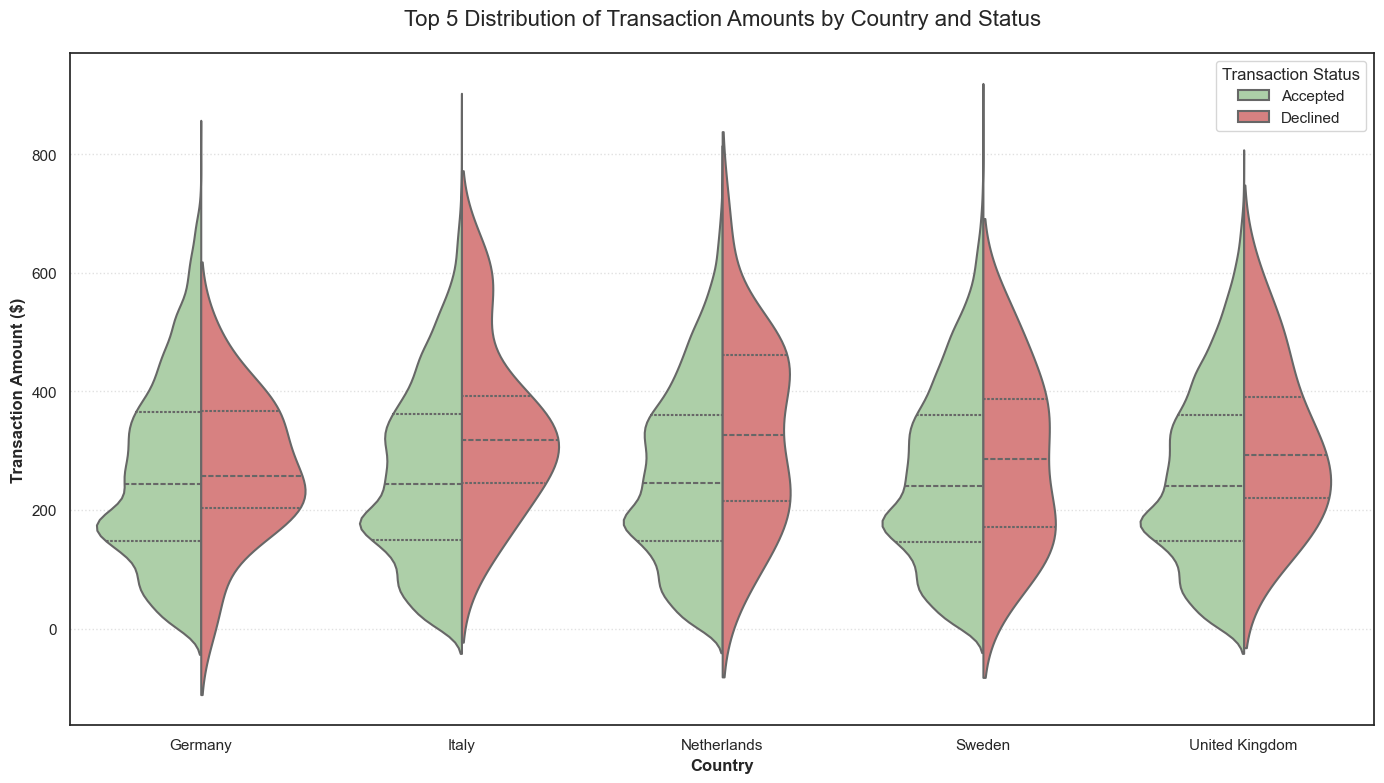

In [34]:
# Merge transactions with companies to get the country field
df = transactions.merge(companies[['company_id', 'country']], on='company_id', how='left')
# Ensure 'amount' is numeric and handle missing values
df['amount'] = pd.to_numeric(df['amount'], errors='coerce').fillna(0)

# Map 0 and 1 to readable names for the legend
df['Status'] = df['declined'].map({0: 'Accepted', 1: 'Declined'})

# Filtering (Top 5 countries by volume to avoid over-crowding)
top_countries = df['country'].value_counts().nlargest(5).index
df_filtered = df[df['country'].isin(top_countries)]

#  Aesthetic Configuration
plt.figure(figsize=(14, 8))
sns.set_style("white")

# Violin Plot Creation

# Order alphabetically
alphabetical_order = sorted(df_filtered['country'].unique())

ax = sns.violinplot(
    data=df_filtered,
    x='country',
    y='amount',
    hue='Status',
    split=True,
    inner="quart",  # Shows quartile lines inside the violin
    palette={'Accepted': '#a8d5a2', 'Declined': '#e57373'},
    linewidth=1.5,
    order = alphabetical_order
)

plt.title('Top 5 Distribution of Transaction Amounts by Country and Status', fontsize=16, pad=20)
plt.xlabel('Country', fontsize=12, fontweight='bold')
plt.ylabel('Transaction Amount ($)', fontsize=12, fontweight='bold')
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend(title='Transaction Status', loc='upper right')
plt.tight_layout()




plt.show()

CONCLUSSIONS:

- Declined transactions generally involve higher amounts: Across all five countries (Germany, Italy, Netherlands, Sweden, and the United Kingdom), the distribution for declined transactions (red) tends to extend further into higher dollar amounts compared to accepted transactions (green)

- Higher Median for Declined Transactions: In countries like the Netherlands and Italy, the median and upper quartile lines for declined transactions are visibly higher than those for accepted transactions, suggesting that larger purchases are more likely to be flagged or rejected

- Netherlands Specificity: The Netherlands shows a particularly high concentration of declined transactions at a much higher price point (around 450) compared to its accepted transactions, which peak closer to 200 dollars

- Consistency in Accepted Transactions: The distribution shape for accepted transactions is remarkably consistent across all five countries, with the majority of successful transactions occurring between 150 and 400 dollars

- Italy and Sweden High-End Risk: Both Italy and Sweden show "tails" in their declined transaction data that reach the highest points on the chart (near $900), indicating that extremely high-value transaction attempts in these countries are frequently declined

The data indicates a strong correlation between higher transaction amounts and a higher likelihood of the transaction being declined across these top five countries


----
### PAIRPLOT
----

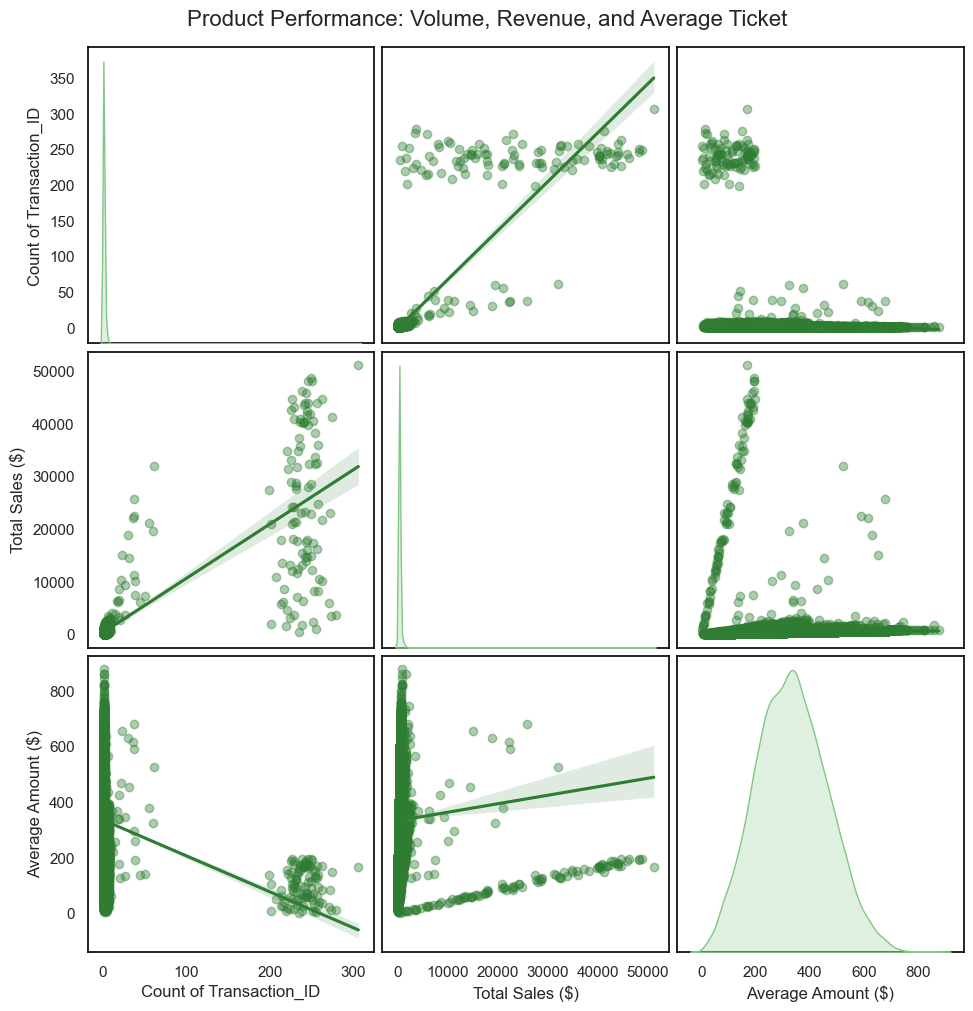

In [15]:
# Added 'mean' for the amount column
df_salesdetails = transactions.groupby('product_id').agg(
    {
        'transaction_id': 'count',
        'amount': ['sum', 'mean']
    }
).reset_index()

# Flatten the multi-index columns created by .agg
df_salesdetails.columns = ['product_id', 'Count of Transaction_ID', 'Total Sales ($)', 'Average Amount ($)']

# plot

sns.set_theme(style="white")
g = sns.pairplot(
    df_salesdetails[['Count of Transaction_ID', 'Total Sales ($)', 'Average Amount ($)']],
    kind='reg',
    diag_kind='kde',
    height=3.3,
    plot_kws={'color': '#2e7d32', 'scatter_kws': {'alpha': 0.4}},
    diag_kws={'color': '#81c784'}
)

# Adding Black Frames to each subplot
for ax in g.axes.flatten():
    if ax:
        plt.setp(ax.spines.values(), visible=True, edgecolor='black', linewidth=1.2)

g.figure.suptitle('Product Performance: Volume, Revenue, and Average Ticket', fontsize=16, y=1.02)
plt.show()

CONCLUSSIONS:

- Distinct Customer Segments: The data reveals two primary clusters of activity. One group is characterized by a high volume of transactions (between 200 and 300) but generally lower average amounts. Another group has a very low transaction count (near zero) but can reach much higher average amounts per transaction

- Inverse Relationship Between Volume and Ticket Size: There is a noticeable negative correlation between the "Count of Transaction_ID" and "Average Amount ($)." As the number of transactions for an ID increases, the average ticket size tends to decrease. This suggests that high-frequency transactions are typically for lower-priced items, while high-value purchases occur less frequently

- Drivers of Total Sales: Total sales are driven by two different patterns:
For one subset of data, sales increase linearly with the average ticket size, likely representing IDs with very few, high-value transactions

- For the high-volume cluster, total sales vary significantly (up to $50,000) despite having consistently low average transaction amounts, meaning total revenue in this segment is driven by the sheer quantity of transactions

- Distribution of Metrics:
The Count of Transaction_ID and Total Sales are both highly skewed, with the vast majority of data points clustered at the lower end of the scale
 -The Average Amount ($) follows a more normal distribution, peaking between 300 and  400 dollars, though it still shows a slight rightward skew towards higher values

-------

# LEVEL 2

## EXERCISE 1

Represent the correlation of some variables and interpret the results based on your data.

--------



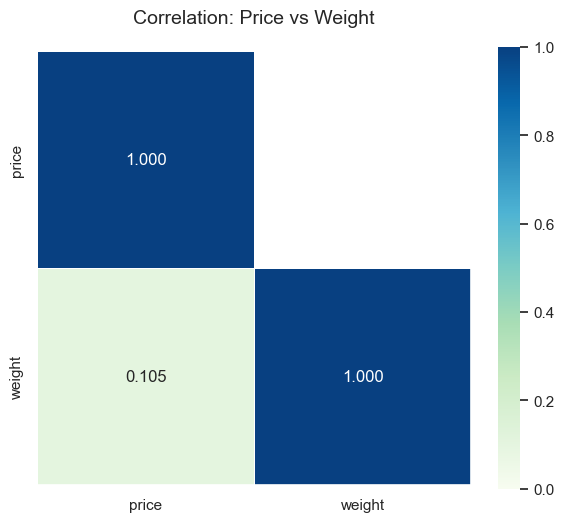

In [16]:
# Calculate the correlation matrix
corr_matrix = products[['price', 'weight']].corr()

# Create the mask for the upper triangle
# np.triu selects the upper triangle.
# k=1 ensures the main diagonal (where values are 1.000) is NOT hidden.
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

plt.figure(figsize=(7, 7))

# Generate Heatmap
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    cmap='GnBu',
    vmin=0,        # Scale starts at 0
    vmax=1,        # Scale ends at 1
    fmt='.3f',
    square=True,
    linewidths=.5,
    # 'shrink' adjusts the height of the colorbar to match the square plot
    cbar_kws={"shrink": .82}
)

plt.title("Correlation: Price vs Weight", fontsize=14, pad=20)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor('white')
    spine.set_linewidth(1.2)

plt.show()

------

## EXERCISE 2

Implement a jointplot to explore the relationship between two variables and interpret the results based on your data.

-------




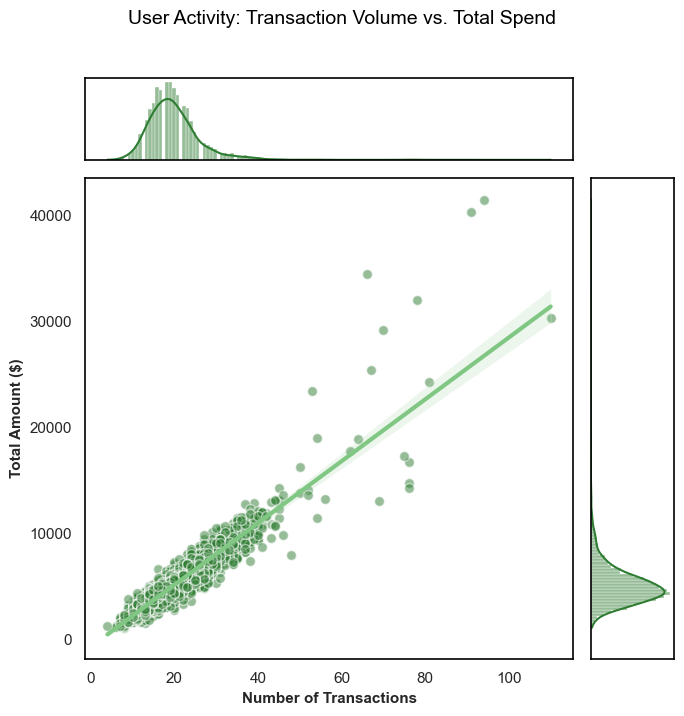

In [17]:

# Convert amount to numeric preventive
transactions['amount'] = pd.to_numeric(transactions['amount'], errors='coerce')

# Group data by user
df_grouped = transactions.groupby('user_id').agg(
    total_amount=('amount', 'sum'),
    number_of_transactions=('transaction_id', 'count')
).reset_index()

sns.set_theme(style="white")

#  Jointplot
g = sns.jointplot(
    data=df_grouped,
    x="number_of_transactions",
    y="total_amount",
    kind="reg",           # Adds regression line and marginal distributions
    height=7,
    color="#2e7d32",
    scatter_kws={'alpha': 0.5, 's': 50, 'edgecolor': 'white'},
    line_kws={'color': '#81c784', 'lw': 3}
)

g.set_axis_labels("Number of Transactions", "Total Amount ($)", fontsize=11, weight="bold")

# Add black frames to the main plot and the marginal plots
for ax in [g.ax_joint, g.ax_marg_x, g.ax_marg_y]:
    plt.setp(ax.spines.values(), visible=True, edgecolor='black', linewidth=1.2)

g.figure.suptitle(
    "User Activity: Transaction Volume vs. Total Spend",
    fontsize=14,
    y=1.02,
    color="black"
)

plt.tight_layout()
plt.show()

------

# LEVEL 3

## EXERCISE 1

Transfer all Level 1 visualizations to Power BI using Python scripts.

-------

In [18]:
# I store my dataframes in a csv to work then whith them in PBI

In [19]:
for df_name, df in dictionary_of_dfs.items():
    df["id_unico"] = df.index
    df.to_csv(f"{df_name}.csv", index = False)

In [20]:
import os
os.getcwd()


'C:\\code\\CURSOS\\BOOTCAMP_DATA_IT ACADEMY_2025_2026\\sprint_11\\tarea_s11_1_sprint_11'